## WorldView Stereopair Processing: SpaceNet UCSD Example

This notebook demonstrates a stereo processing workflow for WorldView-3 satellite imagery using the NASA Ames Stereo Pipeline (ASP).

The example uses publicly available WorldView-3 data from the [IARPA CORE3D](https://www.iarpa.gov/research-programs/core3d) program, hosted as a [SpaceNet Hosted Dataset](https://spacenet.ai/core3d/). This dataset provides multi-temporal L1B imagery over San Diego, California (UCSD campus area) from multiple WorldView-3 and WorldView-2 collections spanning October 2014 to March 2016.

---

### Processing Overview

This notebook covers a basic stereo workflow:

- **Data Retrieval** - Download WorldView-3 imagery from AWS S3
- **Reference DEM Preparation** - Obtain and prepare Copernicus 30m DEM
- **Bundle Adjustment** - Camera model refinement
- **Define Region of Interest** - Select a region of interest for processing
- **Mapprojection** - Project images onto reference DEM
- **Stereo Processing** - Generate DEM from stereopair
- **Visualization with `asp_plot`** - Analyze results and compare with ICESat-2

### Key Differences from the Atlanta Example

| Feature | [SpaceNet Atlanta](worldview_spacenet_atlanta_stereo.ipynb) | CORE3D UCSD (this notebook) |
|---------|--------------------------------------------------------------|----------------------------|
| Sensor | WorldView-2 | **WorldView-3** |
| Temporal | Same-day multi-view (2009-12-22) | **Cross-date pair** (1 day apart) |
| Image format | GeoTIFF tiles | **NITF (NTF)** single strips |
| `wv_correct` | Required (WV2 CCD artifacts) | **Not needed** (WV3 has no CCD boundary artifacts) |
| Mosaicking | Multiple tiles per scene (`dg_mosaic`) | **Single tile per scene** (no mosaicking) |
| Location | Atlanta, GA (UTM 16N) | **San Diego, CA** (UTM 11N) |

The cross-date pairing is more representative of real-world on-demand stereo processing, where users submit pairs from different collection dates.

**Note:** The full UCSD images are very large (~43,000 x 43,000 pixels each). To make processing manageable, we crop to a smaller region of interest.

For advanced workflows including jitter correction, see [ASP Documentation Section 16.39.9](https://stereopipeline.readthedocs.io/en/latest/tools/jitter_solve.html#example-2-worldview-3-digitalglobe-images-on-earth).

<!-- Custom styles to improve notebook rendering: -->
<style>
  .jp-RenderedHTMLCommon pre {
      margin: 1.5em 0;
  }
</style>

---

## Data Retrieval

### IARPA CORE3D UCSD Dataset

[CORE3D](https://www.iarpa.gov/research-programs/core3d) (Creation of Operationally Realistic 3D Environment) was a 3-year IARPA program for automated 3D model creation from satellite imagery. In 2018, IARPA publicly released DigitalGlobe satellite imagery through the SpaceNet S3 bucket.

The UCSD site contains:
- **35 WorldView-3** panchromatic L1B images
- **44 WorldView-2** panchromatic L1B images
- Multi-temporal coverage spanning ~16 months (Oct 2014 – Mar 2016)

The data is hosted on AWS S3 at:

```bash
$ aws s3 ls --no-sign-request s3://spacenet-dataset/Hosted-Datasets/CORE3D-Public-Data/Satellite-Images/UCSD/
                           PRE WV2/
                           PRE WV3/
```

Each image in the `WV3/PAN/` directory includes:
- `*.NTF` — L1B NITF image (JPEG2000 compressed, ~0.8–0.9 GB)
- `*.tar` — Metadata archive containing XML, RPB, IMD, ATT, EPH files needed for ASP

### Selecting a Stereopair

For stereo processing, we want two images with:
- Sufficient angular diversity (convergence angle ~20–35°)
- Good spatial overlap
- Minimal temporal separation (to reduce surface change effects)

#### Available Scenes

The 35 WV3 panchromatic images span a wide range of viewing geometries (all have 0% cloud cover):

| # | Date | CatID | Off-Nadir (°) | Sat Az (°) | Sat El (°) | GSD (m) | Sun El (°) |
|---|------|-------|---------------|------------|------------|---------|------------|
| 1 | 2014-10-27 | `104001000365CA00` | 17.0 | 161.3 | 71.2 | 0.333 | 41.6 |
| 2 | 2014-10-28 | `10400100039E7C00` | 23.2 | 263.8 | 64.4 | 0.356 | 42.3 |
| 3 | 2014-11-09 | `104001000496A100` | 1.1 | 184.8 | 88.6 | 0.308 | 38.1 |
| 4 | 2014-11-22 | `1040010004B41D00` | 13.0 | 227.6 | 75.6 | 0.322 | 35.1 |
| 5 | 2014-11-28 | `10400100047BBB00` | 14.7 | 172.6 | 73.7 | 0.327 | 33.5 |
| 6 | 2014-12-23 | `10400100057DD500` | 24.1 | 132.4 | 63.3 | 0.362 | 30.3 |
| 7 | 2015-01-05 | `1040010005843100` | 8.2 | 146.0 | 80.8 | 0.314 | 31.2 |
| 8 | 2015-01-24 | `10400100071D8800` | 16.3 | 199.2 | 71.8 | 0.332 | 34.3 |
| 9 | 2015-02-06 | `1040010007713300` | 22.6 | 239.3 | 65.0 | 0.355 | 38.2 |
| 10 | 2015-02-11 | `1040010007A3D100` | 24.3 | 81.0 | 63.2 | 0.363 | 37.7 |
| 11 | 2015-02-12 | `1040010007A93700` | 8.4 | 268.3 | 80.8 | 0.315 | 39.6 |
| 12 | 2015-02-24 | `1040010007CA4D00` | 12.9 | 140.4 | 75.7 | 0.323 | 42.7 |
| 13 | 2015-03-21 | `1040010009673900` | 18.7 | 74.4 | 69.5 | 0.338 | 51.7 |
| 14 | 2015-04-10 | `104001000A269C00` | 23.4 | 233.6 | 64.0 | 0.358 | 61.3 |
| 15 | 2015-04-28 | `104001000A3D7E00` | 17.2 | 114.0 | 71.0 | 0.333 | 64.9 |
| 16 | 2015-04-29 | `104001000B230500` | 22.3 | 232.4 | 65.3 | 0.353 | 67.4 |
| 17 | 2015-07-26 | `104001000FCC8E00` | 24.4 | 40.3 | 63.2 | 0.363 | 68.1 |
| 18 | 2015-07-27 | `104001000FBADE00` | 23.7 | 246.4 | 63.7 | 0.360 | 70.7 |
| 19 | 2015-08-08 | `104001000F0EB300` | 21.7 | 197.5 | 65.8 | 0.351 | 67.3 |
| 20 | 2015-08-14 | `104001000F2DF400` | 11.7 | 51.3 | 77.3 | 0.320 | 65.3 |
| 21 | 2015-08-27 | `1040010010339E00` | 19.9 | 211.1 | 67.9 | 0.344 | 63.2 |
| 22 | 2015-09-28 | `104001001159EA00` | 23.6 | 262.8 | 64.0 | 0.358 | 53.8 |
| 23 | 2015-10-23 | `10400100130B9B00` | 21.7 | 221.9 | 66.0 | 0.350 | 44.8 |
| 24 | 2015-11-17 | `1040010013426E00` | 21.9 | 187.1 | 65.6 | 0.351 | 37.1 |
| 25 | 2015-11-23 | `10400100140ED300` | 19.2 | 152.1 | 68.7 | 0.341 | 35.5 |
| 26 | 2015-11-29 | `10400100149C7200` | 24.2 | 77.2 | 63.3 | 0.362 | 33.9 |
| 27 | 2015-12-13 | `1040010014AF5E00` | 22.6 | 247.3 | 65.0 | 0.355 | 33.2 |
| 28 | 2015-12-18 | `10400100162B0400` | 23.5 | 84.2 | 64.0 | 0.358 | 31.7 |
| 29 | 2015-12-25 | `1040010016570500` | 20.4 | 185.0 | 67.3 | 0.345 | 32.1 |
| 30 | 2015-12-31 | `1040010016C57700` | 18.4 | 144.9 | 69.6 | 0.338 | 31.9 |
| 31 | 2016-01-01 | `1040010016091700` | 24.2 | 328.7 | 63.5 | 0.362 | 32.8 |
| 32 | 2016-01-26 | `10400100179C8D00` | 21.9 | 204.9 | 65.7 | 0.351 | 36.1 |
| 33 | 2016-02-08 | `1040010017A92D00` | 21.7 | 230.3 | 65.9 | 0.351 | 39.9 |
| 34 | 2016-02-14 | `1040010018921400` | 21.8 | 197.9 | 65.8 | 0.350 | 41.3 |
| 35 | 2016-02-20 | `10400100190C5100` | 12.1 | 143.1 | 76.5 | 0.321 | 42.8 |

#### Pair Analysis

With 35 images, there are 595 possible stereopairs. To identify the best candidates, we downloaded all 35 metadata archives (~2 MB each) and computed approximate convergence angles and base-to-height (B/H) ratios for every pair using the in-track and cross-track viewing angles from each image’s IMD metadata. The convergence angle is the angular separation between the two satellite viewing directions, computed from the 3D viewing vectors derived from the in-track and cross-track angles. The B/H ratio is related by B/H = 2·tan(θ/2). The azimuth difference indicates how different the two viewing directions are in the horizontal plane — larger values mean the satellite viewed from more opposing sides, which is especially useful in urban areas for resolving building facades.

Of the 595 pairs, 385 fall in the acceptable 15–45° convergence range. The table below shows the top candidates, ranked by temporal proximity (to minimize surface change) and then by convergence angle:

| Rank | Date 1 | CatID 1 | Date 2 | CatID 2 | Conv (°) | B/H | Az Diff (°) | Days Apart |
|------|--------|---------|--------|---------|----------|-----|-------------|------------|
| 1 | 2015-12-31 | `1040010016C57700` | 2016-01-01 | `1040010016091700` | 42.5 | 0.78 | 176.2 | 1 |
| 2 | 2015-04-28 | `104001000A3D7E00` | 2015-04-29 | `104001000B230500` | 33.7 | 0.61 | 118.4 | 1 |
| **3** | **2015-02-11** | **`1040010007A3D100`** | **2015-02-12** | **`1040010007A93700`** | **32.8** | **0.59** | **172.7** | **1** |
| 4 | 2014-10-27 | `104001000365CA00` | 2014-10-28 | `10400100039E7C00` | 31.0 | 0.55 | 102.5 | 1 |
| 5 | 2015-08-08 | `104001000F0EB300` | 2015-08-14 | `104001000F2DF400` | 32.1 | 0.57 | 146.2 | 6 |
| 6 | 2015-11-23 | `10400100140ED300` | 2015-11-29 | `10400100149C7200` | 26.2 | 0.46 | 74.9 | 6 |
| 7 | 2015-12-25 | `1040010016570500` | 2016-01-01 | `1040010016091700` | 42.2 | 0.77 | 143.7 | 7 |
| 8 | 2015-12-18 | `10400100162B0400` | 2015-12-25 | `1040010016570500` | 33.4 | 0.60 | 100.8 | 7 |
| 9 | 2015-11-17 | `1040010013426E00` | 2015-11-29 | `10400100149C7200` | 37.2 | 0.67 | 109.9 | 12 |
| 10 | 2015-08-14 | `104001000F2DF400` | 2015-08-27 | `1040010010339E00` | 31.0 | 0.56 | 159.8 | 13 |

#### Selected Pair

We select **Pair 3** (bolded above):

| Image | Date | CatID | Off-Nadir | Sat Az | GSD (m) |
|-------|------|-------|-----------|--------|---------|
| Image 1 (off-nadir) | 2015-02-11 | `1040010007A3D100` | 24.3° | 81.0° | 0.363 |
| Image 2 (near-nadir) | 2015-02-12 | `1040010007A93700` | 8.4° | 268.3° | 0.315 |

This pair is ideal because:
- **32.8° convergence angle** — solidly in the ideal 20–35° range for urban stereo
- **172.7° azimuth difference** — nearly opposite viewing directions, excellent for resolving building facades
- **1 day apart** — effectively zero surface change
- **One near-nadir (8.4°) + one off-nadir (24.3°)** — good asymmetry for DEM accuracy
- 0% cloud cover on both images

Pair 1 (42.5° convergence) is at the upper limit and may cause more occlusion issues in the urban environment. Pair 2 (33.7°) is also strong but has less azimuth diversity (118° vs 173°).

### Download Commands

Create a working directory and download the NTF images and metadata archives:

```bash
# Create working directory structure
$ mkdir -p ucsd_stereo/images
$ cd ucsd_stereo/images

# Image 1: 2015-02-11, off-nadir (24.3°), WV3
# NTF image (~783 MB)
$ aws s3 --no-sign-request cp \
  s3://spacenet-dataset/Hosted-Datasets/CORE3D-Public-Data/Satellite-Images/UCSD/WV3/PAN/11FEB15WV031200015FEB11182349-P1BS-500647759020_01_P001_________AAE_0AAAAABPABQ0.NTF .
# Metadata tar (~2 MB, contains XML/RPB/IMD/ATT/EPH needed for ASP)
$ aws s3 --no-sign-request cp \
  s3://spacenet-dataset/Hosted-Datasets/CORE3D-Public-Data/Satellite-Images/UCSD/WV3/PAN/11FEB15WV031200015FEB11182349-P1BS-500647759020_01_P001_________AAE_0AAAAABPABQ0.tar .

# Image 2: 2015-02-12, near-nadir (8.4°), WV3
$ aws s3 --no-sign-request cp \
  s3://spacenet-dataset/Hosted-Datasets/CORE3D-Public-Data/Satellite-Images/UCSD/WV3/PAN/12FEB15WV031300015FEB12183926-P1BS-500647760030_01_P001_________AAE_0AAAAABPABS0.NTF .
$ aws s3 --no-sign-request cp \
  s3://spacenet-dataset/Hosted-Datasets/CORE3D-Public-Data/Satellite-Images/UCSD/WV3/PAN/12FEB15WV031300015FEB12183926-P1BS-500647760030_01_P001_________AAE_0AAAAABPABS0.tar .

# Extract metadata from tars
$ for f in *.tar; do tar xf "$f"; done
```

### Examining Contents

The NTF files are NITF-format L1B images. ASP reads NTF files directly via GDAL, so **no format conversion is needed**.

Each tar archive extracts to a structured delivery directory:

```bash
$ ls images/500647759020_01/DVD_VOL_1/500647759020_01/500647759020_01_P001_PAN/

15FEB11182349-P1BS-500647759020_01_P001.ATT
15FEB11182349-P1BS-500647759020_01_P001.EPH
15FEB11182349-P1BS-500647759020_01_P001.GEO
15FEB11182349-P1BS-500647759020_01_P001.IMD
15FEB11182349-P1BS-500647759020_01_P001.RPB
15FEB11182349-P1BS-500647759020_01_P001.XML
```

The important files for ASP processing are:
- `*.NTF` — The NITF image file
- `*.XML` — The metadata file containing RPC camera model information

Unlike the [Atlanta example](worldview_spacenet_atlanta_stereo.ipynb), each UCSD image is delivered as a **single strip** (one tile), so no mosaicking with `dg_mosaic` is needed.

### Preparing Symbolic Links

Create symbolic links with short, descriptive names using the CatID:

```bash
$ cd ucsd_stereo

# Image 1 (2015-02-11, off-nadir)
$ ln -s images/11FEB15WV031200015FEB11182349-P1BS-500647759020_01_P001_________AAE_0AAAAABPABQ0.NTF \
  1040010007A3D100_P001.NTF
$ ln -s images/500647759020_01/DVD_VOL_1/500647759020_01/500647759020_01_P001_PAN/15FEB11182349-P1BS-500647759020_01_P001.XML \
  1040010007A3D100_P001.xml

# Image 2 (2015-02-12, near-nadir)
$ ln -s images/12FEB15WV031300015FEB12183926-P1BS-500647760030_01_P001_________AAE_0AAAAABPABS0.NTF \
  1040010007A93700_P001.NTF
$ ln -s images/500647760030_01/DVD_VOL_1/500647760030_01/500647760030_01_P001_PAN/15FEB12183926-P1BS-500647760030_01_P001.XML \
  1040010007A93700_P001.xml
```

### Stereo Geometry Analysis

Before processing, it's useful to analyze the stereo acquisition geometry to verify the convergence angle and other geometric properties. We use `asp_plot` to visualize the geometry from the XML camera metadata:

Auto-detected UTM projection: EPSG:32611
Scene extent (lon/lat): -117.309973 32.805066 -117.135093 32.945083


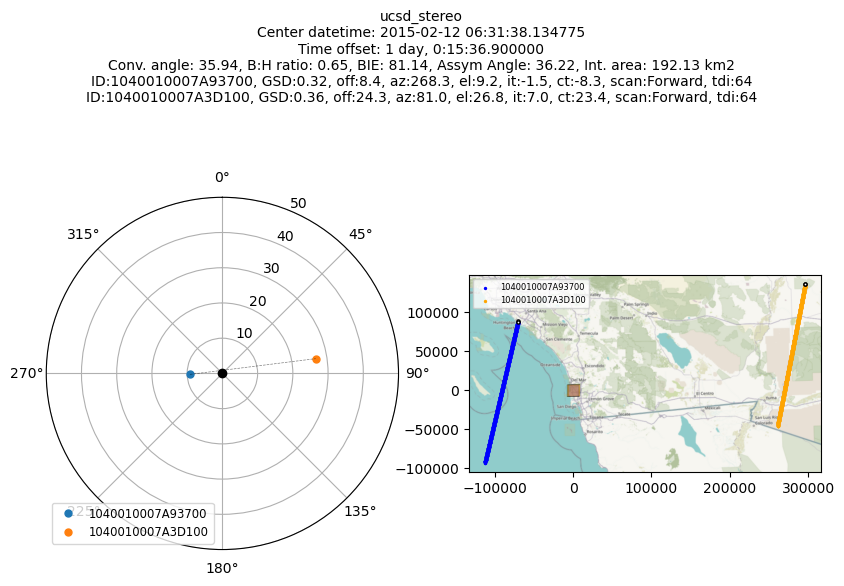

In [1]:
# Set the base directory for your processing
directory = "/Users/ben/Library/CloudStorage/Dropbox/UW_Shean/asp_plot-test_data/docs_examples/ucsd_stereo/"
# directory = "/path/to/your/ucsd_stereo/"

# Create geometry plotter and auto-detect UTM projection and scene extent from XML metadata
from asp_plot.stereo_geometry import StereoGeometryPlotter

sgp = StereoGeometryPlotter(directory)
utm_code = sgp.get_pair_utm_epsg()
map_crs = f"EPSG:{utm_code}"
scene_bounds = sgp.get_scene_bounds()

print(f"Auto-detected UTM projection: {map_crs}")
print(f"Scene extent (lon/lat): {scene_bounds[0]:.6f} {scene_bounds[1]:.6f} {scene_bounds[2]:.6f} {scene_bounds[3]:.6f}")

# Generate the geometry plot
sgp.dg_geom_plot()

### Satellite Position and Orientation Data

The XML camera metadata also contains ephemeris (position/velocity) and attitude (orientation quaternion) data reported by the satellite during acquisition. Visualizing this data can help assess the quality of the raw metadata before ASP processing.

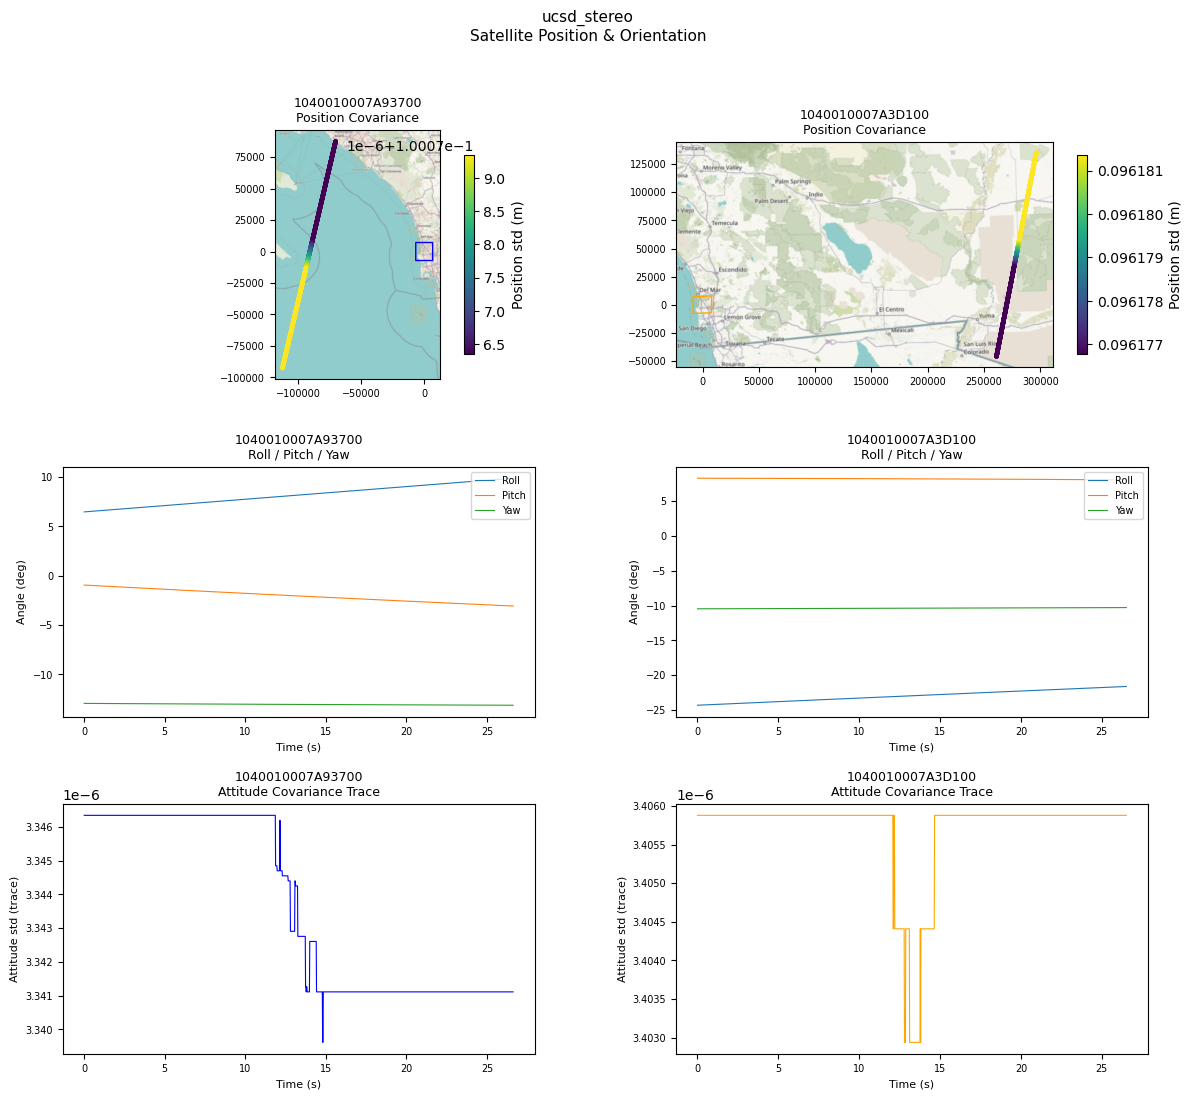

In [2]:
sgp.satellite_position_orientation_plot()

In the above plot:

- Top row (Position Covariance): A map showing the satellite's path over the ground during image capture, colored by how uncertain the satellite's reported position is (in meters). Lower values mean the satellite knows where it is more precisely.

- Middle row (Roll / Pitch / Yaw): Shows how the satellite's pointing deviates from its expected nadir-pointing orientation over time. Roll is rotation around the flight direction, pitch is rotation around the cross-track axis, and yaw is rotation around the nadir axis. Values near zero mean the satellite is pointing straight down. These are computed by comparing the raw attitude quaternions against a reference orientation estimated from the satellite's orbital position and velocity.

- Bottom row (Attitude Covariance Trace): Shows how uncertain the satellite's orientation knowledge is over time. Lower values mean the satellite is more confident about which direction it's pointing. Spikes or jumps indicate moments of less reliable pointing knowledge, which could affect image quality in those portions of the scene.

---

## CCD Artifact Correction — Not Needed for WorldView-3

The [`wv_correct`](https://stereopipeline.readthedocs.io/en/latest/tools/wv_correct.html) tool is used to correct subpixel CCD boundary misalignment artifacts in WorldView-1 and WorldView-2 imagery. These artifacts manifest as discontinuities in DEMs at CCD boundaries.

**WorldView-3 does not suffer from the same CCD boundary artifacts**, so `wv_correct` is **not needed** for this dataset and we skip this step entirely.

For comparison, see the [Atlanta example](worldview_spacenet_atlanta_stereo.ipynb) where `wv_correct` is applied to WorldView-2 imagery.

---

## Processing Configuration

Before proceeding with the main processing steps, we define key parameters that will be used throughout the workflow.

```bash
$ cd ucsd_stereo

# Target spatial reference system
# The UTM EPSG code was auto-detected from the input image XML metadata above
# For San Diego, California this is EPSG:32611 (UTM Zone 11N)
$ t_srs="EPSG:32611"

# Scene extent from the union of both image footprints (auto-detected above)
# Format: "min_lon min_lat max_lon max_lat"
$ scene_bounds="-117.310 32.805 -117.135 32.945"

# Buffer by ~100 m (~0.001 degrees) for reference DEM download
$ scene_bounds=$(echo $scene_bounds | awk '{printf "%.6f %.6f %.6f %.6f", $1-0.001, $2-0.001, $3+0.001, $4+0.001}')

# Output resolution for mapproject (meters)
# Use the more nadir image's meanProductGSD from the IMD metadata
# For this WorldView-3 pair, Image 2 (near-nadir) has meanProductGSD of ~0.315 m
$ tr=0.315

# Reference DEM filename (WGS84 ellipsoid heights, projected to UTM)
$ reference_dem_fn="ref/cop30_ucsd_wgs84_utm.tif"
```

**Notes:**
- The `t_srs` and `scene_bounds` were auto-detected from the XML camera metadata — see the code cell above
- The `meanProductGSD` value can be found in the `*.IMD` metadata file for each image
- We use the near-nadir image's GSD as the target resolution since it has the finest native resolution
- The output DEM will be generated at a coarser resolution (4x the input GSD)

---

## Reference DEM Preparation

A reference DEM is required for:
- Mapprojecting the input images
- Validating the output DEM

We use the Copernicus 30m GLO-30 DEM, which provides global coverage with good accuracy.

### Download Copernicus DEM with Ellipsoid Heights

We download with [fetch_dem](https://github.com/uw-cryo/fetch_dem). This requires a free [OpenTopography API key](https://portal.opentopography.org/requestService?service=api).

**Important:** We use `-demtype COP30_E` to download the DEM with **WGS84 ellipsoid heights** directly. ASP requires heights relative to the WGS84 ellipsoid.

The `-extent` argument uses the `scene_bounds` defined above, which corresponds to the union of both image footprints. Ensure that the extent has full coverage over the area you are attempting to process.

```bash
$ cd ucsd_stereo

# Download Copernicus DEM with ellipsoid heights (COP30_E)
$ python /path/to/your/fetch_dem/download_global_DEM.py \
  -demtype COP30_E \
  -extent "$scene_bounds" \
  -out_fn "$reference_dem_fn" \
  -out_proj "$t_srs" \
  -apikey [YOUR_OPEN_TOPOGRAPHY_API_KEY]
```

This command creates the reference DEM at `ref/cop30_ucsd_wgs84_utm.tif` with WGS84 ellipsoid heights in UTM Zone 11N projection.

---

## Bundle Adjustment

Bundle adjustment refines camera models by minimizing reprojection errors of matched feature points. This step improves stereo correlation quality.

The [`bundle_adjust`](https://stereopipeline.readthedocs.io/en/latest/tools/bundle_adjust.html) tool **must be run on the full images** without any further cropping to a region of interest. This is critical because:
- Camera models need to be optimized using tie points across the entire image
- The refined camera parameters apply globally to each image
- Cropping before bundle adjustment would limit the tie point coverage and potentially degrade the camera model quality

Since WV3 does not require `wv_correct`, we use the NTF images directly:

```bash
$ cd ucsd_stereo

$ bundle_adjust \
  --threads 24 \
  --ip-per-image 10000 \
  --tri-weight 0.1 \
  --tri-robust-threshold 0.1 \
  --camera-weight 0 \
  1040010007A3D100_P001.NTF 1040010007A93700_P001.NTF \
  1040010007A3D100_P001.xml 1040010007A93700_P001.xml \
  -o ba/run
```

**Key parameters:**
- `--ip-per-image 10000`: Detect many interest points for robust matching
- `--tri-weight 0.1`: Weight for triangulation consistency constraint
- `--camera-weight 0`: Allow cameras to move freely (no prior constraint)

**Note on cross-date pairs:** Since these images were collected 1 day apart, surface changes are negligible. The nearly opposite satellite azimuths (81° vs 268°) mean building facades will appear differently in each image, which may reduce matching in dense urban areas but is not a problem for the bundle adjustment solver when sufficient tie points are available.

### Bundle Adjustment Results

Visualize the bundle adjustment results to verify the optimization reduced reprojection errors:

In [ ]:
from asp_plot.bundle_adjust import ReadBundleAdjustFiles, PlotBundleAdjustFiles
import contextily as ctx

# Define subdirectories
bundle_adjust_directory = "ba/"
stereo_directory = "stereo/"

# Map configuration (map_crs was auto-detected in the geometry cell above)
ctx_kwargs = {
    "crs": map_crs,
    "source": ctx.providers.Esri.WorldImagery,
    "attribution_size": 0,
    "alpha": 0.5,
}

# Read bundle adjustment residuals
ba_files = ReadBundleAdjustFiles(directory, bundle_adjust_directory)
resid_initial_gdf, resid_final_gdf = ba_files.get_initial_final_residuals_gdfs(residuals_in_meters=True)

# Plot residuals before and after optimization
plotter = PlotBundleAdjustFiles(
    [resid_initial_gdf, resid_final_gdf],
    lognorm=True,
    title="Bundle Adjust Initial and Final Residuals"
)
plotter.plot_n_gdfs(
    column_name="mean_residual",
    cbar_label="Mean residual (px)",
    map_crs=map_crs,
    **ctx_kwargs
)

---

## Define Region of Interest

The full UCSD images are very large (~43,000 x 43,000 pixels each). To make processing tractable, we define a region of interest to process.

You could determine the overlapping region interactively using [`stereo_gui`](https://stereopipeline.readthedocs.io/en/latest/tools/stereo_gui.html):

```bash
$ stereo_gui 1040010007A3D100_P001.NTF 1040010007A93700_P001.NTF 1040010007A3D100_P001.xml 1040010007A93700_P001.xml
```

Draw a bounding box on the overlap area by holding down <kbd>Ctrl</kbd> and clicking to draw a box, then noting the pixel coordinates in the terminal output.

**However**, more practically, you can use any other tool to collect appropriate coordinates to define a geographic bounding box for your region of interest. Just be sure the region is contained in the overlapping area of the two selected images.

The `mapproject` tool accepts coordinates with `--t_projwin` in the target projection. The format is: `xmin ymin xmax ymax`, which corresponds to:

- `xmin`: Western edge
- `ymin`: Southern edge
- `xmax`: Eastern edge
- `ymax`: Northern edge

### Option A: Manual ROI Selection

For this example, we defined a ~5.6 x 6.7 km region of interest covering the UCSD campus and the steep terrain of Mount Soledad and Torrey Pines to the southwest toward La Jolla:

```bash
# Define the region of interest in UTM Zone 11N (EPSG:32611) as "xmin ymin xmax ymax"
$ t_projwin="475200 3633000 480800 3639700"
```

### Option B: Use Full Intersection Extent

Alternatively, you can use the full overlap (intersection) extent of the two input images as your processing window. The `get_intersection_bounds()` method computes this from the XML camera metadata and reprojects to your target UTM CRS:

In [ ]:
# Get the intersection extent in UTM coordinates (from the geometry cell above)
intersection_bounds = sgp.get_intersection_bounds(epsg=utm_code)
t_projwin = f"{intersection_bounds[0]:.0f} {intersection_bounds[1]:.0f} {intersection_bounds[2]:.0f} {intersection_bounds[3]:.0f}"
print(f"Intersection projwin: {t_projwin}")

And then use that output for the `t_projwin` variable.

**Note:** Processing the full intersection can be significantly more compute-intensive than a small ROI. Consider starting with a smaller region (Option A) for initial testing.

---

Using a single projected bounding box is simpler than pixel coordinates because:
- The same region works for both images
- `mapproject` automatically determines which source pixels to read
- Easier to define regions based on real-world locations using the GIS tool of your choosing. [Here's a particularly good one](https://geojson.io/#map=2/0/20)

---

## Mapprojection

Mapprojection orthorectifies the images onto the reference DEM surface. This simplifies stereo correlation by removing most geometric distortions, leaving only parallax due to elevation differences.

We use the [`mapproject`](https://stereopipeline.readthedocs.io/en/latest/tools/mapproject.html) tool to project only the ROI using the bundle-adjusted cameras:

```bash
$ cd ucsd_stereo

# Mapproject Image 1 (1040010007A3D100) to the ROI
$ mapproject \
  -t rpc \
  --processes 48 \
  --threads 24 \
  --tr $tr \
  --t_projwin $t_projwin \
  --t_srs "$t_srs" \
  --bundle-adjust-prefix ba/run \
  "$reference_dem_fn" \
  1040010007A3D100_P001.NTF 1040010007A3D100_P001.xml \
  1040010007A3D100_P001_map.tif

# Mapproject Image 2 (1040010007A93700) to the same ROI
$ mapproject \
  -t rpc \
  --processes 48 \
  --threads 24 \
  --tr $tr \
  --t_projwin $t_projwin \
  --t_srs "$t_srs" \
  --bundle-adjust-prefix ba/run \
  "$reference_dem_fn" \
  1040010007A93700_P001.NTF 1040010007A93700_P001.xml \
  1040010007A93700_P001_map.tif
```

**Key parameters:**
- `-t rpc`: Use RPC model for camera, which is fast
- `--tr $tr`: Output resolution (0.315 m, the near-nadir image's meanProductGSD)
- `--t_srs`: Target spatial reference system (EPSG:32611 for UTM Zone 11N)
- `--t_projwin`: Region of interest in projected coordinates (xmin ymin xmax ymax)
- `--bundle-adjust-prefix`: Use the refined camera models from bundle adjustment

---

## Stereo Processing

Run stereo correlation on the mapprojected (and cropped) images to generate a point cloud and DEM using the [`parallel_stereo`](https://stereopipeline.readthedocs.io/en/latest/tools/parallel_stereo.html) tool:

```bash
$ cd ucsd_stereo

$ parallel_stereo \
  --stereo-algorithm asp_mgm \
  --subpixel-mode 9 \
  --processes 24 \
  --alignment-method none \
  --bundle-adjust-prefix ba/run \
  1040010007A3D100_P001_map.tif 1040010007A93700_P001_map.tif \
  1040010007A3D100_P001.xml 1040010007A93700_P001.xml \
  stereo/run \
  "$reference_dem_fn"
```

**Key parameters:**
- `--stereo-algorithm asp_mgm`: Use ASP's implementation of Semi-Global Matching
- `--subpixel-mode 9`: High-quality subpixel refinement
- `--alignment-method none`: Images are already aligned via mapprojection
- `--bundle-adjust-prefix ba/run`: Use bundle-adjusted camera models

### Generate 1.2 m DEM

Given the ~0.315 m spatial resolution of the near-nadir image, we generate a ~1.2 m DEM from the result with the [`point2dem`](https://stereopipeline.readthedocs.io/en/latest/tools/point2dem.html) tool. Using a DEM resolution of approximately 4x the input image resolution helps reduce noise and improves output quality:

```bash
$ point2dem \
  --tr 1.2 \
  --t_srs "$t_srs" \
  --errorimage \
  stereo/run-PC.tif
```

The `--errorimage` flag produces an intersection error map showing triangulation consistency, which is useful as a quick DEM quality assessment.

### Compute Difference vs Reference

We can also use the [`geodiff`](https://stereopipeline.readthedocs.io/en/latest/tools/geodiff.html) tool to create a quick difference map of the available reference DEM for comparison in the coming plots.

```bash
$ geodiff \
  stereo/run-DEM.tif \
  "$reference_dem_fn" \
  -o stereo/run_vs_ref
```

### Stereo Results Visualization

Examine the stereo processing outputs to assess DEM quality:

In [ ]:
from asp_plot.stereo import StereoPlotter
from asp_plot.scenes import ScenePlotter

# Plot input scenes (mapprojected images)
scene_plotter = ScenePlotter(directory, stereo_directory, title="Mapprojected Input Scenes")
scene_plotter.plot_scenes()

# Plot DEM results
stereo_plotter = StereoPlotter(directory, stereo_directory)
stereo_plotter.title = "Stereo DEM Results"
stereo_plotter.plot_dem_results()

# Plot detailed hillshade with zoom subsets
stereo_plotter.title = "Hillshade with Details"
stereo_plotter.plot_detailed_hillshade(subset_km=0.5)

---

## Comprehensive Report and ICESat-2 Altimetry Validation

In addition to the inline visualizations above, we can validate the ASP DEM against ICESat-2 ATL06-SR altimetry data. This provides an independent accuracy assessment using satellite laser altimetry.

The sections below demonstrate ICESat-2 comparison and generate a comprehensive PDF report.

### Setup

After you have `asp_plot` installed and ready to use, you can set up the directory and file names:

In [ ]:
# Set the base directory for your processing
# directory = "/path/to/your/ucsd_stereo/"
directory = "/Users/ben/Library/CloudStorage/Dropbox/UW_Shean/asp_plot-test_data/docs_examples/ucsd_stereo/"

# Define subdirectories for bundle adjustment and stereo results
bundle_adjust_directory = "ba/"
stereo_directory = "stereo/" 

### Full Report Generation

Generate a comprehensive PDF report with a single CLI command:

#### **Note:** You can [view the full report here](https://github.com/uw-cryo/asp_plot/blob/main/reports/WorldView_UCSD-asp-plot-report.pdf).

In [ ]:
!asp_plot \
  --directory $directory \
  --bundle_adjust_directory $bundle_adjust_directory \
  --stereo_directory $stereo_directory \
  --map_crs $map_crs \
  --plot_icesat True \
  --plot_geometry True

### ICESat-2 Altimetry Validation

Compare the ASP DEM with ICESat-2 ATL06-SR altimetry data:

In [ ]:
from asp_plot.altimetry import Altimetry

In [ ]:
icesat = Altimetry(
  directory=directory,
  dem_fn=stereo_plotter.dem_fn
)

In [ ]:
# Request ATL06-SR data (single "all" processing level)
icesat.request_atl06sr_multi_processing(
    processing_levels=["all"],
    save_to_parquet=True,
)

In [ ]:
# Filter out water bodies
icesat.filter_esa_worldcover(filter_out="water")

No temporal filtering needed for the simplified report workflow.
Advanced temporal filtering is still available via:

```py
icesat.predefined_temporal_filter_atl06sr(date=...)
icesat.generic_temporal_filter_atl06sr(select_years=..., select_months=..., ...)
```

In [ ]:
# Map view of ICESat-2 vs DEM differences
icesat.mapview_plot_atl06sr_to_dem(
    key="all",
    map_crs=map_crs,
    **ctx_kwargs,
)

In [ ]:
# Histogram with per-landcover-class statistics
icesat.histogram_by_landcover(key="all")

In [ ]:
# Profile along the best ICESat-2 track
icesat.plot_atl06sr_dem_profile(key="all")

### DEM-to-Altimetry Alignment

Run `pc_align` to compute the translation required to align the DEM with ICESat-2 data:

**Note on multiple pc_align runs:** The `alignment_report` method runs `pc_align` once for each temporal filter (e.g., "ground", "ground_seasonal", etc.). This allows comparison of alignment results across different subsets of ICESat-2 data. Each row in the resulting DataFrame represents a separate alignment run.

The output columns include:
- `north_shift`, `east_shift`, `down_shift`: Translation vector in North-East-Down coordinates (meters)
- `p16_beg/end`, `p50_beg/end`, `p84_beg/end`: Error percentiles before and after alignment

In [ ]:
# Run alignment report to assess DEM quality
icesat.alignment_report(
    processing_level="all",
    minimum_points=100,
    agreement_threshold=0.25,
    write_out_aligned_dem=True,
)

In [ ]:
icesat.alignment_report_df

In [ ]:
# Histogram of aligned DEM vs ICESat-2 differences
icesat.atl06sr_to_dem_dh()

icesat.histogram(
    key="all",
    plot_aligned=True,
)

---

## Next Steps

This notebook demonstrated a basic cross-date stereo workflow with WorldView-3 imagery. For more advanced processing:

- **Full-resolution processing**: Remove the crop windows to process the entire image overlap (requires significant compute resources)
- **Jitter correction**: For highest quality DEMs, apply jitter correction following [ASP Documentation Section 16.39.9](https://stereopipeline.readthedocs.io/en/latest/tools/jitter_solve.html#example-2-worldview-3-digitalglobe-images-on-earth)
- **Multi-view stereo**: Process additional pairs from the 35 WV3 + 44 WV2 images in the CORE3D UCSD dataset and merge the resulting DEMs
- **Additional stereo pairs**: The pair analysis table above shows several other strong pairs — try the Apr 28/29 pair (33.7° convergence, summer imagery) or the Oct 27/28 pair (31.0° convergence, fall imagery) to compare seasonal effects